In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('data/churn.csv')
df.sample(5)

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
2216,5,0,37,0,1120,17,7,11,2,1,2,25,82.665,0
2956,15,0,41,2,3375,56,300,20,4,1,1,45,835.775,0
2091,0,0,24,0,520,4,14,1,4,1,2,45,48.100,0
19,3,0,37,0,7508,127,384,43,2,1,1,25,2071.575,0
149,0,0,7,0,1428,16,0,5,3,1,1,30,57.760,1


<Axes: xlabel='Churn'>

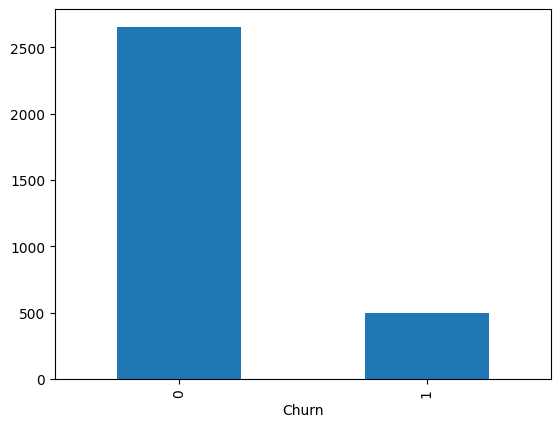

In [6]:
df.Churn.value_counts().plot(kind='bar')

In [7]:
df.isnull().sum()

Call  Failure              0
Complains                  0
Subscription  Length       0
Charge  Amount             0
Seconds of Use             0
Frequency of use           0
Frequency of SMS           0
Distinct Called Numbers    0
Age Group                  0
Tariff Plan                0
Status                     0
Age                        0
Customer Value             0
Churn                      0
dtype: int64

In [8]:
x=df.drop('Churn',axis='columns')
y=df['Churn']

# Model training

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=40)
model=LogisticRegression(max_iter=2000)
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.93      0.97      0.95       547
           1       0.69      0.49      0.58        83

    accuracy                           0.90       630
   macro avg       0.81      0.73      0.76       630
weighted avg       0.90      0.90      0.90       630



C:\Users\Jeevan kumar\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Handeling class imbalance

In [14]:
from imblearn.under_sampling import RandomUnderSampler
rus=RandomUnderSampler(random_state=42)
X_train_rus,y_train_rus=rus.fit_resample(x_train,y_train)
X_train_rus.value_counts()

Call  Failure  Complains  Subscription  Length  Charge  Amount  Seconds of Use  Frequency of use  Frequency of SMS  Distinct Called Numbers  Age Group  Tariff Plan  Status  Age  Customer Value
0              0          37                    0               0               0                 0                 0                        2          1            2       25   0.000             6
                          35                    0               0               0                 0                 0                        2          1            2       25   0.000             5
                          33                    0               0               0                 0                 0                        2          1            2       25   0.000             4
                          34                    0               0               0                 0                 0                        2          1            2       25   0.000             4
               

In [15]:
X_train_rus

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value
862,31,1,39,4,15850,236,62,32,3,1,1,30,891.440
2274,19,0,42,3,6203,106,43,30,3,1,1,30,424.360
697,10,0,16,3,3042,46,40,22,3,1,1,30,283.520
513,0,0,38,0,2495,17,462,7,3,1,1,30,1948.480
1286,0,0,29,0,1280,36,21,14,3,1,2,30,136.640
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1018,0,0,37,0,0,0,0,0,2,1,2,25,0.000
2981,11,0,39,0,1643,24,24,6,4,1,2,45,101.675
3027,8,0,37,0,1863,39,16,33,3,1,2,30,140.080
1231,0,1,38,0,403,3,12,6,4,1,2,45,40.150


In [16]:
y_train_rus.value_counts()

Churn
0    412
1    412
Name: count, dtype: int64

In [17]:
model=LogisticRegression(max_iter=2000)
model.fit(X_train_rus,y_train_rus)

y_pred=model.predict(x_test)
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.98      0.81      0.88       547
           1       0.41      0.89      0.56        83

    accuracy                           0.82       630
   macro avg       0.70      0.85      0.72       630
weighted avg       0.91      0.82      0.84       630



C:\Users\Jeevan kumar\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Smote

In [20]:
from imblearn.over_sampling import SMOTE

smote=SMOTE(random_state=42)
x_train_smote,y_train_smote=smote.fit_resample(x_train,y_train)

In [21]:
y_train_smote.value_counts()

Churn
0    2108
1    2108
Name: count, dtype: int64

In [22]:
model=LogisticRegression(max_iter=2000)
model.fit(x_train_smote,y_train_smote)

y_pred=model.predict(x_test)
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.79      0.87       547
           1       0.37      0.84      0.52        83

    accuracy                           0.79       630
   macro avg       0.67      0.81      0.69       630
weighted avg       0.89      0.79      0.82       630



C:\Users\Jeevan kumar\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Smotetomek

In [23]:
from imblearn.combine import SMOTETomek

tomek=SMOTETomek(random_state=42)
x_train_tomek,y_train_tomek=tomek.fit_resample(x_train,y_train)
y_train_tomek.value_counts()

Churn
0    2073
1    2073
Name: count, dtype: int64

In [24]:
model=LogisticRegression(max_iter=2000)
model.fit(x_train_tomek,y_train_tomek)

y_pred=model.predict(x_test)
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.79      0.87       547
           1       0.38      0.84      0.52        83

    accuracy                           0.80       630
   macro avg       0.67      0.82      0.70       630
weighted avg       0.89      0.80      0.83       630



C:\Users\Jeevan kumar\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
